# Tutorial 1

> Tutorial 1

In [ ]:
#| default_exp tutorial_1

In [ ]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from bioMONAI.core import *
from bioMONAI.core import Path
from bioMONAI.data import get_image_files, get_target, RandomSplitter
from bioMONAI.nets import BasicUNet, DynUNet
from bioMONAI.losses import *
from bioMONAI.metrics import *
from bioMONAI.datasets import download_medmnist

from monai.utils import set_determinism
from monai.transforms import ScaleIntensity

set_determinism(0)

In [ ]:
device = get_device()
print(device)

cpu


CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343995622/work/c10/cuda/CUDAFunctions.cpp:109.)


### Download Data

In [ ]:
image_path = '../_data/medmnist_data/'
# download_medmnist('pathmnist', image_path, download_only=True)

### Create Dataloader

In [ ]:
from fastai.vision.all import *

In [ ]:
bs, size = 16, 128

path = Path(image_path)
path_train = path/'train'
path_val = path/'val'


data_ops = {
    'blocks':       (BioImageBlock(cls=BioImageStack), CategoryBlock),
    'get_items':    get_image_files,
    'get_y':        parent_label,
    'splitter':     GrandparentSplitter(),
    'item_tfms':    [ScaleIntensity(minv=0.0, maxv=1.0)],
    'bs': bs,
}

data = get_dataloader(
    path, 
    show_summary=True,
    **data_ops,
    )

# print length of training and validation datasets
print('train images:', len(data.train_ds.items), '\nvalidation images:', len(data.valid_ds.items))

Setting affine, but the applied meta contains an affine. This will be overwritten.


Setting-up type transforms pipelines
Found 107180 items
2 datasets of sizes 85744,21436
Setting up Pipeline: BioImageProject.create
Setting up Pipeline: parent_label -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}

Building one sample
  Pipeline: BioImageProject.create
    starting from
      ../_data/medmnist_data/train/6/train_59711.tiff
    applying BioImageProject.create gives
      BioImageProject of size 1x28x28
  Pipeline: parent_label -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}
    starting from
      ../_data/medmnist_data/train/6/train_59711.tiff
    applying parent_label gives
      6
    applying Categorize -- {'vocab': None, 'sort': True, 'add_na': False} gives
      TensorCategory(6)

Final sample: (BioImage([[[217., 232., 242., 228., 193., 193., 229., 243., 245., 237., 222.,
          228., 223., 198., 190., 192., 171., 194., 197., 188., 194., 185.,
          231., 240., 215., 151., 179., 200.],
         [230., 226., 238., 196., 215., 

Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.


Setting affine, but the applied meta contains an affine. This will be overwritten.


IndexError: tuple index out of range

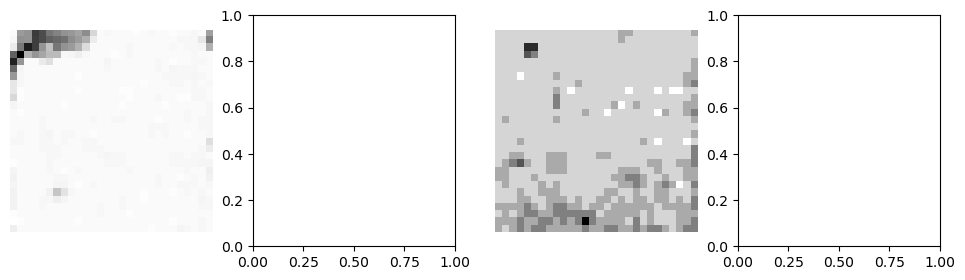

In [ ]:
data.show_batch(max_n=2, cmap='gray')

### Load and train a 2D model

In [ ]:
from bioMONAI.nets import Deeplab, DeeplabConfig

In [ ]:
config_2d = DeeplabConfig(
    dimensions=2,
    in_channels=1,  
    out_channels=1,
    backbone="resnet10",  
    aspp_dilations=[1, 6, 12, 18]
)
model = Deeplab(config_2d)
 
loss = MSSSIML1Loss(2, levels=2) #CombinedLoss(alpha=0, beta=0.5)
metrics = [SSIMMetric, MSELoss]

trainer = fastTrainer(data, model, loss_fn=loss, metrics=metrics, show_summary=False)

In [ ]:
trainer.fit_flat_cos(500)

In [ ]:
trainer.show_results(cmap='gray')

In [ ]:
# trainer.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!